# Analyze PCA-source a priori subset selection
This notebook visualizes the geometry-based rule outputs from `run_pca_source_rank_weight.py`:
- target coverage curve: C90(k)
- training diversity curve: D(k)
- selected k and whether the rule triggered early

In [23]:
from pathlib import Path
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

def find_project_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / 'src').exists() and (p / 'outputs').exists():
            return p
    return start

def pick_csv(base_dir: Path, filename: str) -> Path:
    candidates = [
        base_dir / filename,
        *sorted(base_dir.glob(f'*/{filename}')),
        *sorted(base_dir.glob(f'*/*/{filename}')),
    ]
    path = next((p for p in candidates if p.exists()), None)
    if path is None:
        raise FileNotFoundError(f'{filename} not found under {base_dir}')
    return path

ROOT = find_project_root(Path.cwd().resolve())
print('ROOT:', ROOT)

ROOT: C:\Users\Simen\OneDrive - NTNU\FYSMAT\INDMAT\MASTER\Master_thesis


In [24]:
# Set this to your desired run folder
out_dir = ROOT / 'outputs' / 'pca_source_rank_weight_test4'

results_path = pick_csv(out_dir, 'pca_source_rank_weight_results.csv')
diag_path = pick_csv(out_dir, 'pca_source_apriori_diagnostics.csv')
summary_path = pick_csv(out_dir, 'pca_source_rank_weight_summary.csv')

results = pd.read_csv(results_path)
diag = pd.read_csv(diag_path)
summary = pd.read_csv(summary_path)

print('Loaded results   :', results_path)
print('Loaded diag      :', diag_path)
print('Loaded summary   :', summary_path)
print('Rows -> results:', len(results), 'diag:', len(diag), 'summary:', len(summary))

Loaded results   : C:\Users\Simen\OneDrive - NTNU\FYSMAT\INDMAT\MASTER\Master_thesis\outputs\pca_source_rank_weight_test4\pca_source_rank_weight_results.csv
Loaded diag      : C:\Users\Simen\OneDrive - NTNU\FYSMAT\INDMAT\MASTER\Master_thesis\outputs\pca_source_rank_weight_test4\pca_source_apriori_diagnostics.csv
Loaded summary   : C:\Users\Simen\OneDrive - NTNU\FYSMAT\INDMAT\MASTER\Master_thesis\outputs\pca_source_rank_weight_test4\pca_source_rank_weight_summary.csv
Rows -> results: 1712 diag: 160 summary: 416


In [25]:
# Filters
n_components_filter = None   # e.g. [10, 20]
target_filter = None         # e.g. ['Aldra', 'Lovund']

d = diag.copy()
d['n_components'] = pd.to_numeric(d['n_components'], errors='coerce').astype('Int64')
d['k'] = pd.to_numeric(d['k'], errors='coerce').astype('Int64')
d['selected_k'] = pd.to_numeric(d['selected_k'], errors='coerce').astype('Int64')

if n_components_filter is not None:
    keep = set(int(x) for x in n_components_filter)
    d = d[d['n_components'].isin(keep)].copy()

if target_filter is not None:
    keep_t = set(str(x) for x in target_filter)
    d = d[d['target_island_name'].astype(str).isin(keep_t)].copy()

if d.empty:
    raise ValueError('No diagnostic rows after filtering.')

sel_rows = d[d['selected_row'] == True].copy()
n_targets = sel_rows['target_island_name'].nunique()
n_pcs = sel_rows['n_components'].nunique()
n_early = int(sel_rows['triggered_early'].sum())

print(f'Targets: {n_targets} | PC settings: {n_pcs}')
print(f'Early-trigger rows: {n_early} / {len(sel_rows)}')
display(sel_rows[['trait', 'target_island_name', 'n_components', 'selected_k', 'c90_full', 'diversity_full', 'triggered_early']].sort_values(['n_components', 'target_island_name']).reset_index(drop=True))

Targets: 16 | PC settings: 1
Early-trigger rows: 16 / 16


,trait,target_island_name,n_components,selected_k,c90_full,diversity_full,triggered_early
0,body_mass,Aldra,10,3000,10.885908,71.893586,True
1,body_mass,Gjerøy,10,2500,11.151469,74.242774,True
2,body_mass,Hestmannøy,10,2500,8.839418,76.484607,True
3,body_mass,Indre Kvarøy,10,3000,9.470485,73.346438,True
4,body_mass,Lovund,10,3000,10.489410,73.359415,True
5,body_mass,Myken,10,3000,9.179438,73.326596,True
6,body_mass,Nesøy,10,3000,8.945626,73.707965,True
7,body_mass,Onøy og Lurøy,10,3000,9.820720,73.897758,True
8,body_mass,Selvær,10,3000,9.853701,73.545687,True
9,body_mass,Sleneset,10,3000,8.186293,73.020976,True


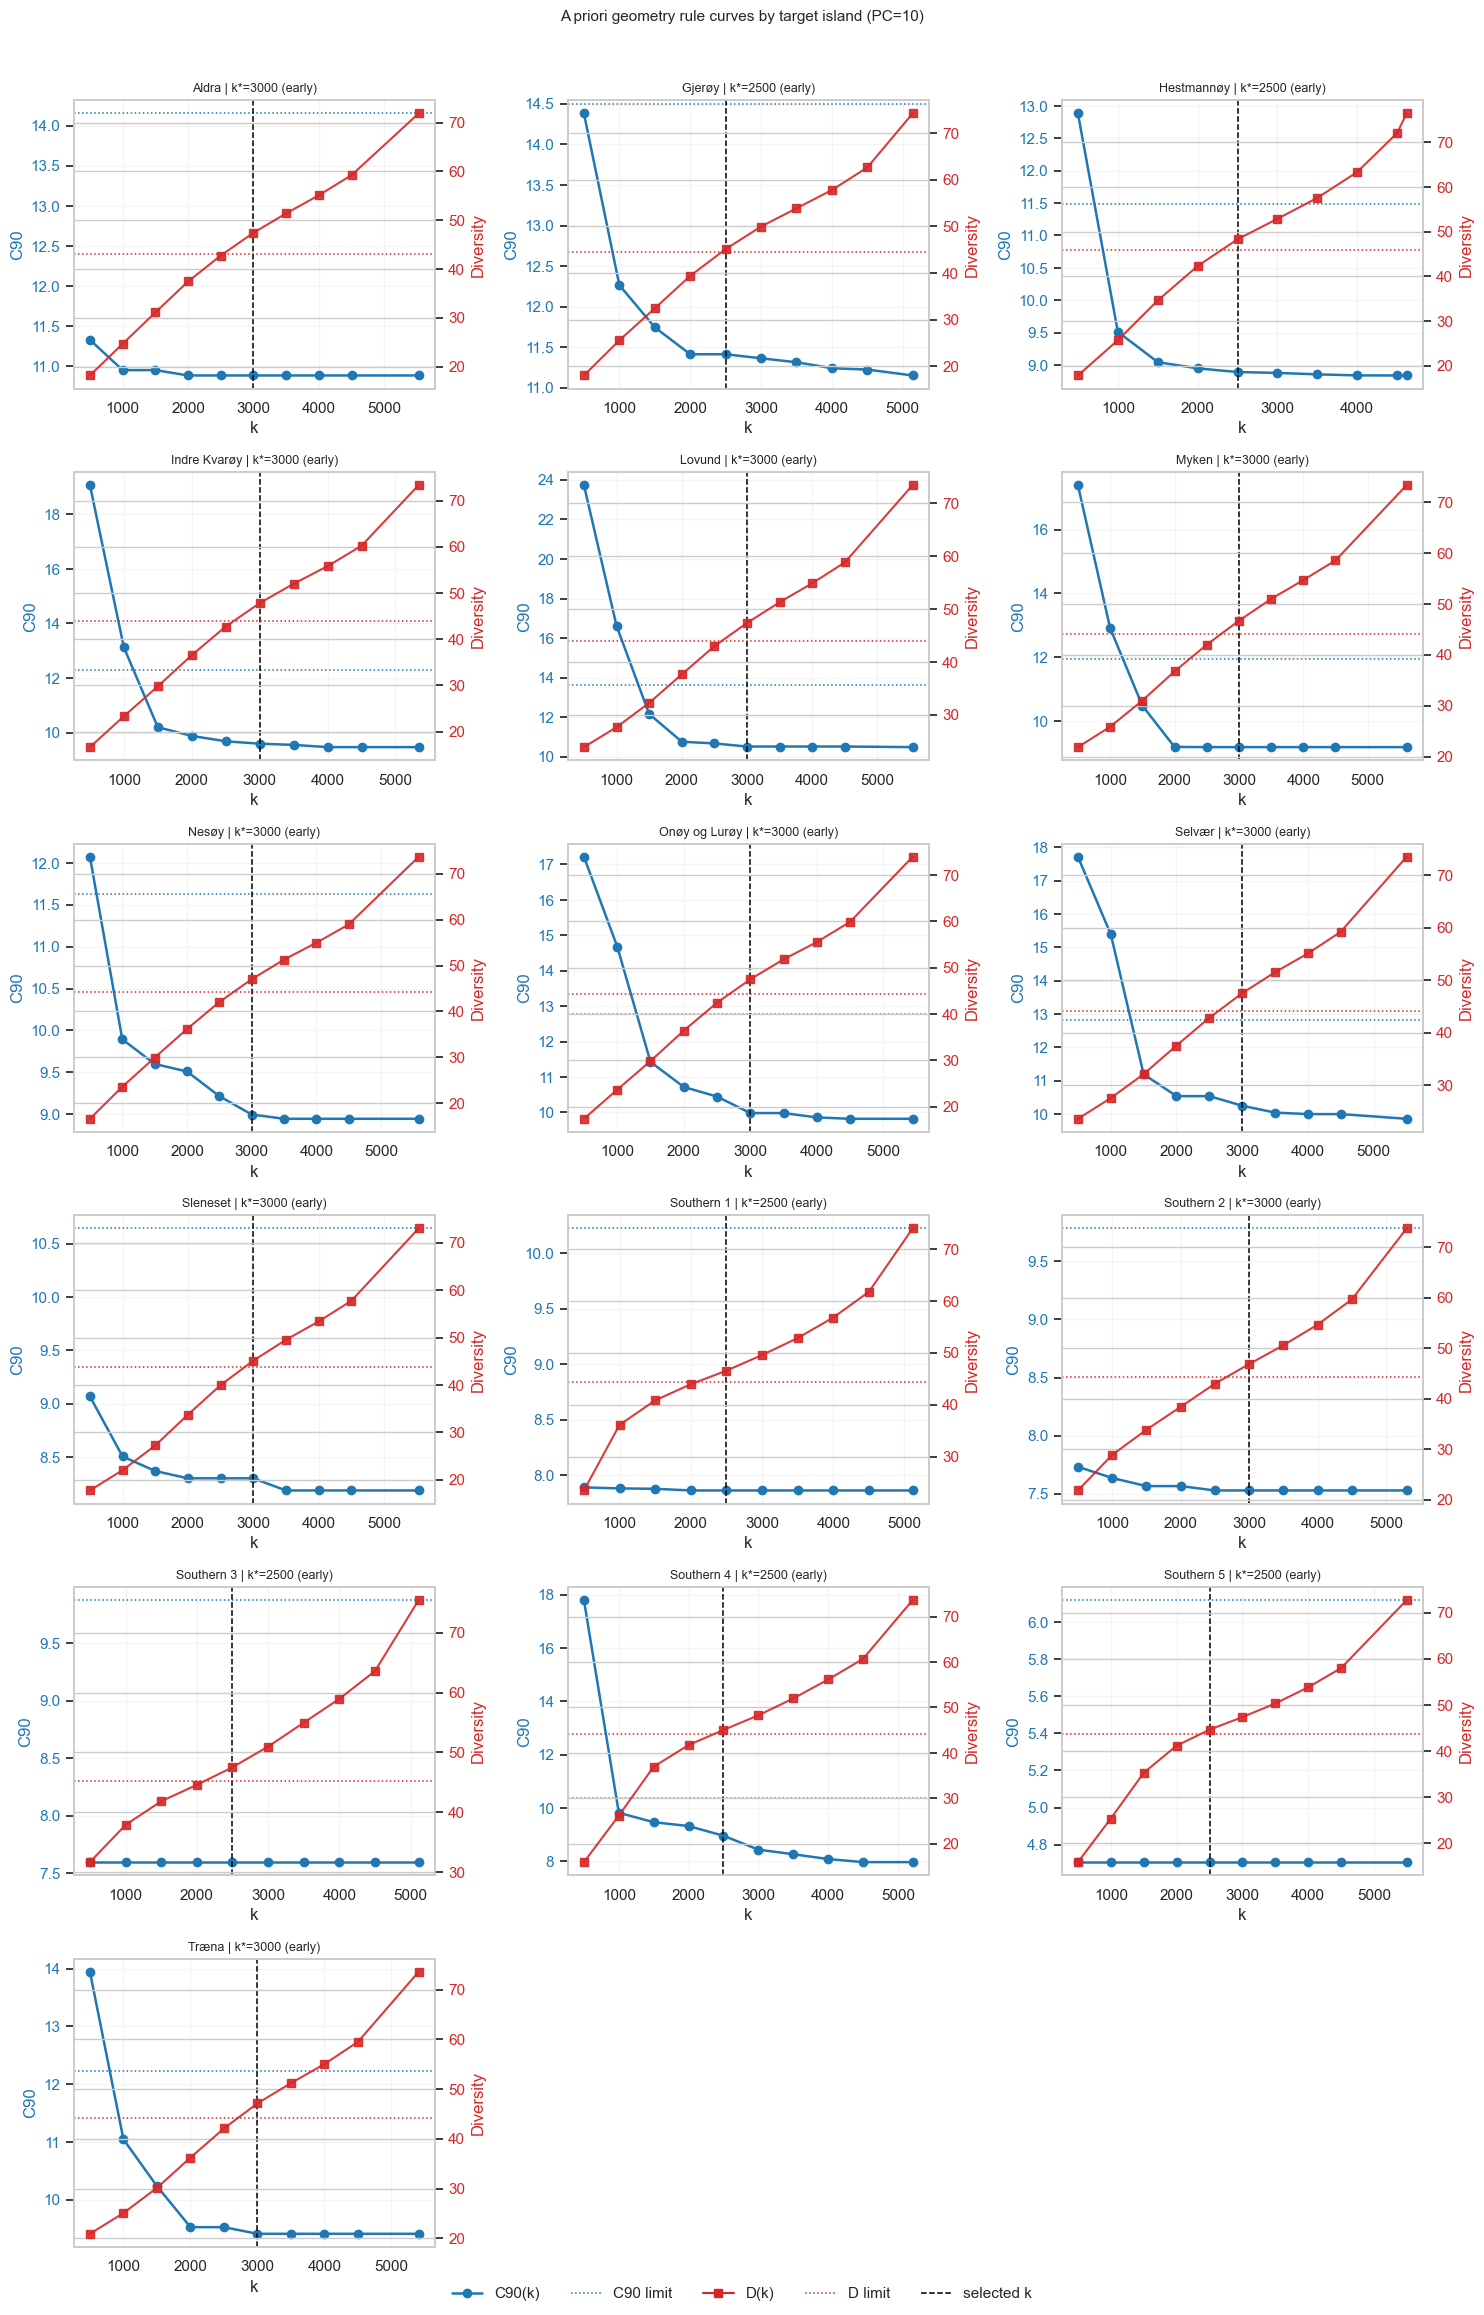

In [26]:
# Curves per target: C90(k) and D(k), faceted by target island
targets = sorted(d['target_island_name'].astype(str).unique().tolist())
pcs = sorted(pd.to_numeric(d['n_components'], errors='coerce').dropna().astype(int).unique().tolist())

for pc in pcs:
    dpc = d[d['n_components'].astype(int) == int(pc)].copy()
    if dpc.empty:
        continue

    n_panels = len(targets)
    n_cols = min(3, n_panels)
    n_rows = int(math.ceil(n_panels / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5.0, n_rows * 3.8), squeeze=False, sharex=False)

    for ax, tgt in zip(axes.flatten(), targets):
        sub = dpc[dpc['target_island_name'].astype(str) == str(tgt)].sort_values('k')
        if sub.empty:
            ax.set_visible(False)
            continue

        ax2 = ax.twinx()

        ax.plot(sub['k'], sub['c90'], color='#1f77b4', marker='o', linewidth=1.8, label='C90(k)')
        ax.axhline(float(sub['c90_limit'].iloc[0]), color='#1f77b4', linestyle=':', linewidth=1.1, label='C90 limit')

        ax2.plot(sub['k'], sub['diversity'], color='#d62728', marker='s', linewidth=1.5, alpha=0.9, label='D(k)')
        ax2.axhline(float(sub['diversity_limit'].iloc[0]), color='#d62728', linestyle=':', linewidth=1.1, label='D limit')

        sel = sub[sub['selected_row'] == True]
        if len(sel):
            k_sel = int(sel['k'].iloc[0])
            ax.axvline(k_sel, color='black', linestyle='--', linewidth=1.1)
            early = bool(sel['triggered_early'].iloc[0])
            tag = 'early' if early else 'full'
            ax.set_title(f'{tgt} | k*={k_sel} ({tag})', fontsize=9)
        else:
            ax.set_title(str(tgt), fontsize=9)

        ax.set_xlabel('k')
        ax.set_ylabel('C90', color='#1f77b4')
        ax2.set_ylabel('Diversity', color='#d62728')
        ax.tick_params(axis='y', labelcolor='#1f77b4')
        ax2.tick_params(axis='y', labelcolor='#d62728')
        ax.grid(alpha=0.2)

    for ax in axes.flatten()[n_panels:]:
        ax.set_visible(False)

    h1 = plt.Line2D([0], [0], color='#1f77b4', marker='o', lw=1.8, label='C90(k)')
    h2 = plt.Line2D([0], [0], color='#1f77b4', ls=':', lw=1.1, label='C90 limit')
    h3 = plt.Line2D([0], [0], color='#d62728', marker='s', lw=1.5, label='D(k)')
    h4 = plt.Line2D([0], [0], color='#d62728', ls=':', lw=1.1, label='D limit')
    h5 = plt.Line2D([0], [0], color='black', ls='--', lw=1.1, label='selected k')
    fig.legend(handles=[h1, h2, h3, h4, h5], loc='lower center', ncol=5, frameon=False)
    fig.suptitle(f'A priori geometry rule curves by target island (PC={pc})', y=1.01, fontsize=11)
    fig.tight_layout()
    plt.show()

,trait,target_island_name,n_components,apriori_k,best_fixed_k,full_k,apriori_corr,best_fixed_corr,full_corr,k_ratio_vs_fixed_best,k_ratio_vs_full,corr_delta_vs_fixed_best,corr_delta_vs_full
0,body_mass,Aldra,10.0,3000.0,4500,5524.0,0.300978,0.359753,0.329256,0.666667,0.543085,-0.058775,-0.028278
1,body_mass,Gjerøy,10.0,2500.0,1500,5139.0,0.127164,0.137573,0.088359,1.666667,0.486476,-0.010409,0.038806
2,body_mass,Hestmannøy,10.0,2500.0,1000,4619.0,0.129037,0.137480,0.138178,2.500000,0.541243,-0.008443,-0.009141
3,body_mass,Indre Kvarøy,10.0,3000.0,4500,5341.0,0.286931,0.327008,0.318762,0.666667,0.561693,-0.040077,-0.031831
4,body_mass,Lovund,10.0,3000.0,4500,5539.0,0.339755,0.368998,0.386991,0.666667,0.541614,-0.029243,-0.047237
5,body_mass,Myken,10.0,3000.0,2500,5605.0,0.382187,0.393762,0.337273,1.200000,0.535236,-0.011575,0.044914
6,body_mass,Nesøy,10.0,3000.0,500,5578.0,0.192723,0.268354,0.207697,6.000000,0.537827,-0.075631,-0.014973
7,body_mass,Onøy og Lurøy,10.0,3000.0,500,5438.0,-0.006806,0.138314,-0.002500,6.000000,0.551673,-0.145120,-0.004305
8,body_mass,Selvær,10.0,3000.0,1000,5503.0,0.210345,0.263430,0.218657,3.000000,0.545157,-0.053085,-0.008312
9,body_mass,Sleneset,10.0,3000.0,4500,5531.0,0.159517,0.191896,0.161706,0.666667,0.542397,-0.032379,-0.002188


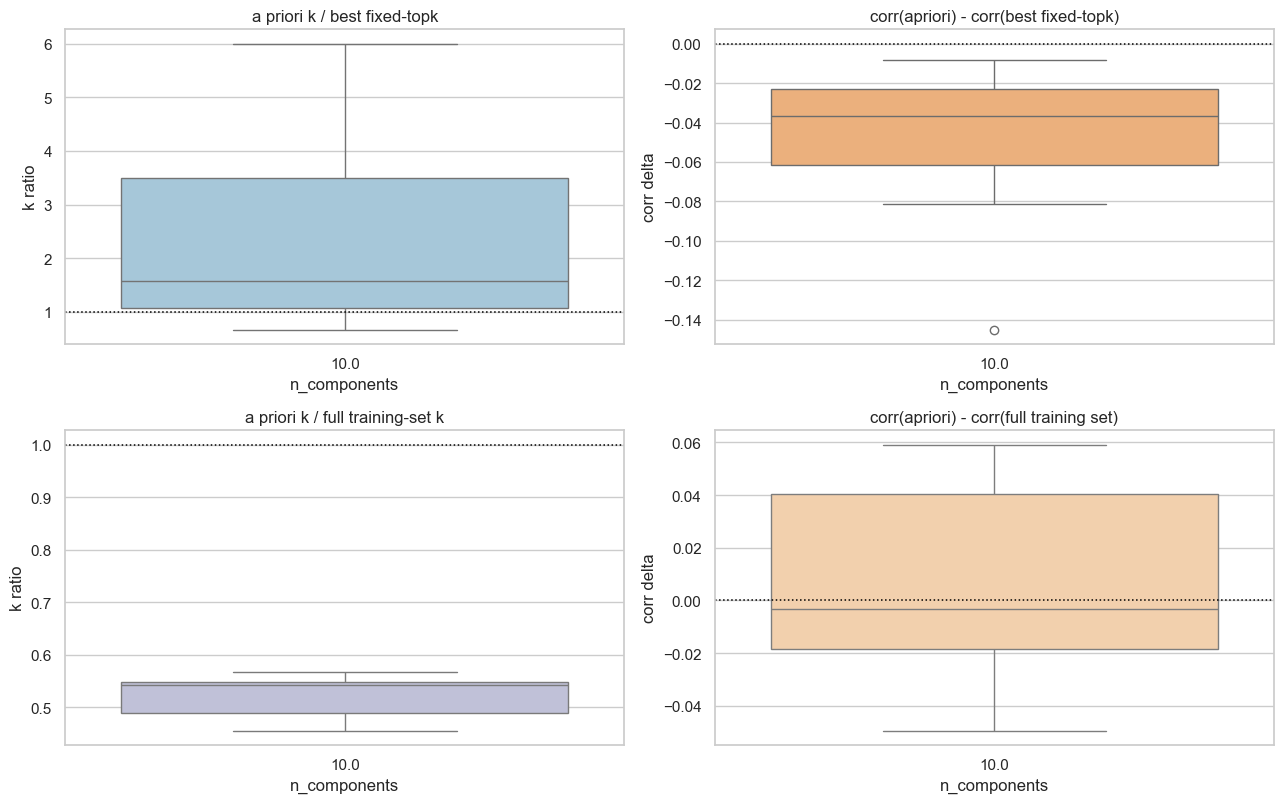

In [27]:
# Compare selected a priori method against fixed top-k and full training set
res = results.copy()
res['n_components'] = pd.to_numeric(res['n_components'], errors='coerce')

ap = res[res['method'] == 'pca_source_apriori_topk'].copy()
fx = res[res['method'] == 'pca_source_topk'].copy()
full = res[res['method'] == 'full_source_unweighted'].copy()

if n_components_filter is not None:
    keep = set(int(x) for x in n_components_filter)
    ap = ap[ap['n_components'].astype('Int64').isin(keep)]
    fx = fx[fx['n_components'].astype('Int64').isin(keep)]

if target_filter is not None:
    keep_t = set(str(x) for x in target_filter)
    ap = ap[ap['target_island_name'].astype(str).isin(keep_t)]
    fx = fx[fx['target_island_name'].astype(str).isin(keep_t)]
    full = full[full['target_island_name'].astype(str).isin(keep_t)]

# Build fixed-topk best per trait/target/PC by corr_eval
fx_best = (
    fx.groupby(['trait', 'target_island_name', 'n_components', 'n_individuals'], as_index=False)
    .agg(corr_eval=('corr_eval', 'mean'))
    .sort_values(['trait', 'target_island_name', 'n_components', 'corr_eval'], ascending=[True, True, True, False])
)
fx_best = fx_best.groupby(['trait', 'target_island_name', 'n_components'], as_index=False).first()
fx_best = fx_best.rename(columns={'n_individuals': 'best_fixed_k', 'corr_eval': 'best_fixed_corr'})

# Full-training-set reference (one per trait/target across repeats)
full_ref = (
    full.groupby(['trait', 'target_island_name'], as_index=False)
    .agg(full_k=('n_individuals', 'mean'), full_corr=('corr_eval', 'mean'))
)

ap_mean = (
    ap.groupby(['trait', 'target_island_name', 'n_components'], as_index=False)
    .agg(apriori_k=('n_individuals', 'mean'), apriori_corr=('corr_eval', 'mean'))
)

cmp_df = ap_mean.merge(fx_best, on=['trait', 'target_island_name', 'n_components'], how='left')
cmp_df = cmp_df.merge(full_ref, on=['trait', 'target_island_name'], how='left')
cmp_df['k_ratio_vs_fixed_best'] = cmp_df['apriori_k'] / cmp_df['best_fixed_k']
cmp_df['corr_delta_vs_fixed_best'] = cmp_df['apriori_corr'] - cmp_df['best_fixed_corr']
cmp_df['k_ratio_vs_full'] = cmp_df['apriori_k'] / cmp_df['full_k']
cmp_df['corr_delta_vs_full'] = cmp_df['apriori_corr'] - cmp_df['full_corr']

display(
    cmp_df.sort_values(['trait', 'n_components', 'target_island_name']).reset_index(drop=True)
    [['trait', 'target_island_name', 'n_components', 'apriori_k', 'best_fixed_k', 'full_k',
      'apriori_corr', 'best_fixed_corr', 'full_corr',
      'k_ratio_vs_fixed_best', 'k_ratio_vs_full',
      'corr_delta_vs_fixed_best', 'corr_delta_vs_full']]
)

if len(cmp_df):
    fig, axes = plt.subplots(2, 2, figsize=(13, 8.2))

    sns.boxplot(data=cmp_df, x='n_components', y='k_ratio_vs_fixed_best', color='#9ecae1', ax=axes[0, 0])
    axes[0, 0].axhline(1.0, color='black', linestyle=':', linewidth=1.1)
    axes[0, 0].set_title('a priori k / best fixed-topk')
    axes[0, 0].set_xlabel('n_components')
    axes[0, 0].set_ylabel('k ratio')

    sns.boxplot(data=cmp_df, x='n_components', y='corr_delta_vs_fixed_best', color='#fdae6b', ax=axes[0, 1])
    axes[0, 1].axhline(0.0, color='black', linestyle=':', linewidth=1.1)
    axes[0, 1].set_title('corr(apriori) - corr(best fixed-topk)')
    axes[0, 1].set_xlabel('n_components')
    axes[0, 1].set_ylabel('corr delta')

    sns.boxplot(data=cmp_df, x='n_components', y='k_ratio_vs_full', color='#bcbddc', ax=axes[1, 0])
    axes[1, 0].axhline(1.0, color='black', linestyle=':', linewidth=1.1)
    axes[1, 0].set_title('a priori k / full training-set k')
    axes[1, 0].set_xlabel('n_components')
    axes[1, 0].set_ylabel('k ratio')

    sns.boxplot(data=cmp_df, x='n_components', y='corr_delta_vs_full', color='#fdd0a2', ax=axes[1, 1])
    axes[1, 1].axhline(0.0, color='black', linestyle=':', linewidth=1.1)
    axes[1, 1].set_title('corr(apriori) - corr(full training set)')
    axes[1, 1].set_xlabel('n_components')
    axes[1, 1].set_ylabel('corr delta')

    fig.tight_layout()
    plt.show()